## Assignment 1: Supply Chain Analytics with Vectors, Matrices, and Systems of Equations
DATA-605, Computational Mathematics, Fall 2026

Supervised by: **Professor Jose Jorge Pagan**


Submitted by: **Mehreen Ali Gillani**

###    Topics

-   Vectors
-   Matrices
-   Systems of Linear Equations

#### Import libraries

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
inventory_df = pd.read_csv('data/inventory.csv')
demand_df = pd.read_csv('data/demand.csv')
shipments_df = pd.read_csv('data/shipments.csv')

# Display the data
print("=== INVENTORY DATA ===")
print(inventory_df)
print("\n=== DEMAND DATA ===")
print(demand_df)
print("\n=== SHIPMENT DATA ===")
print(shipments_df)


=== INVENTORY DATA ===
  Warehouse  Region1  Region2  Region3
0         A     1200      900      800
1         B     1000     1100      700
2         C      900      700     1000

=== DEMAND DATA ===
    Region  Demand
0  Region1    2800
1  Region2    2400
2  Region3    2500

=== SHIPMENT DATA ===
  Warehouse  Region1  Region2  Region3
0         A      300      400      500
1         B      400      350      250
2         C      500      300      200


## PART A: INVENTORY ANALYSIS USING VECTORS

In [62]:
# Extract inventory data as vectors
# Each row represents a warehouse, each column represents a region
inventory_matrix = inventory_df.iloc[:, 1:4].values
print(f"\nInventory Matrix (Warehouses x Regions):\n{inventory_matrix}")

# Extract demand as a vector
demand_vector = demand_df['Demand'].values
print(f"\nDemand Vector:\n{demand_vector}")


Inventory Matrix (Warehouses x Regions):
[[1200  900  800]
 [1000 1100  700]
 [ 900  700 1000]]

Demand Vector:
[2800 2400 2500]


### Task 1: Calculate total inventory available in each region

In [63]:

# Sum inventory across all warehouses for each region
total_inventory_regions = np.sum(inventory_matrix, axis=0) # axis=0 sums down the rows, giving total per column (region)
print(f"\nTask 1: Total Inventory Available in Each Region")
print(f"Region 1: {total_inventory_regions[0]} units")
print(f"Region 2: {total_inventory_regions[1]} units")
print(f"Region 3: {total_inventory_regions[2]} units")



Task 1: Total Inventory Available in Each Region
Region 1: 3100 units
Region 2: 2700 units
Region 3: 2500 units


# Task 2: Calculate inventory surplus or shortage relative to demand

In [64]:

# Surplus = Total Inventory - Demand (positive = surplus, negative = shortage, zero = balanced)
surplus_shortage = total_inventory_regions - demand_vector
print(f"\nTask 2: Inventory Surplus/Shortage by Region")
# Using a helper function or list comprehension
status = lambda x: 'SURPLUS' if x > 0 else 'SHORTAGE' if x < 0 else 'BALANCED'
for i, region in enumerate(['Region1', 'Region2', 'Region3']):
    print(f"{region}: {surplus_shortage[i]:+.0f} units ({status(surplus_shortage[i])})")


Task 2: Inventory Surplus/Shortage by Region
Region1: +300 units (SURPLUS)
Region2: +300 units (SURPLUS)
Region3: +0 units (BALANCED)


# Task 3: Identify which region is most at risk of stock shortages

In [65]:
region_names = ['Region1', 'Region2', 'Region3']
print("\nTask 3: Region Most at Risk of Stock Shortages")
min_surplus = np.min(surplus_shortage)
if min_surplus < 0:
    most_at_risk = region_names[np.argmin(surplus_shortage)]
    print(f"{most_at_risk} is most at risk with a shortage of {abs(min_surplus):.0f} units")
elif min_surplus == 0:
    vulnerable = region_names[np.argmin(surplus_shortage)]
    print(f"No immediate shortages, but {vulnerable} is exactly balanced (0 surplus) and most vulnerable to demand increases")
else:
    print(f" All regions have surplus inventory - no risk of shortages")
    smallest_surplus = region_names[np.argmin(surplus_shortage)]
    print(f"Note: {smallest_surplus} has the smallest surplus ({min_surplus:.0f} units)")



Task 3: Region Most at Risk of Stock Shortages
No immediate shortages, but Region3 is exactly balanced (0 surplus) and most vulnerable to demand increases


# Additional analysis: Percentage shortfall/surplus

In [66]:
percentage_change = (surplus_shortage / demand_vector) * 100
print(f"\nPercentage Surplus/Shortage by Region:")
for i, region in enumerate(region_names):
    print(f"{region}: {percentage_change[i]:+.1f}%")


Percentage Surplus/Shortage by Region:
Region1: +10.7%
Region2: +12.5%
Region3: +0.0%


### Inventory vs. Demand by Region

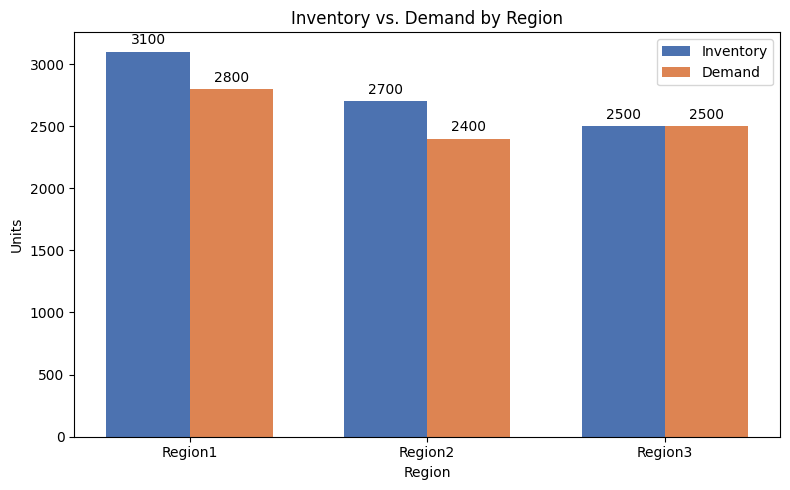

In [67]:
fig, ax = plt.subplots(figsize=(8, 5))

x_pos = np.arange(len(region_names))
width = 0.35

bars1 = ax.bar(x_pos - width/2, total_inventory_regions, width, label='Inventory', color='#4C72B0')
bars2 = ax.bar(x_pos + width/2, demand_vector, width, label='Demand', color='#DD8452')

ax.set_xlabel('Region')
ax.set_ylabel('Units')
ax.set_title('Inventory vs. Demand by Region')
ax.set_xticks(x_pos)
ax.set_xticklabels(region_names)
ax.legend()
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)

plt.tight_layout()
plt.show()

### Inventory Surplus/Shortage by Region

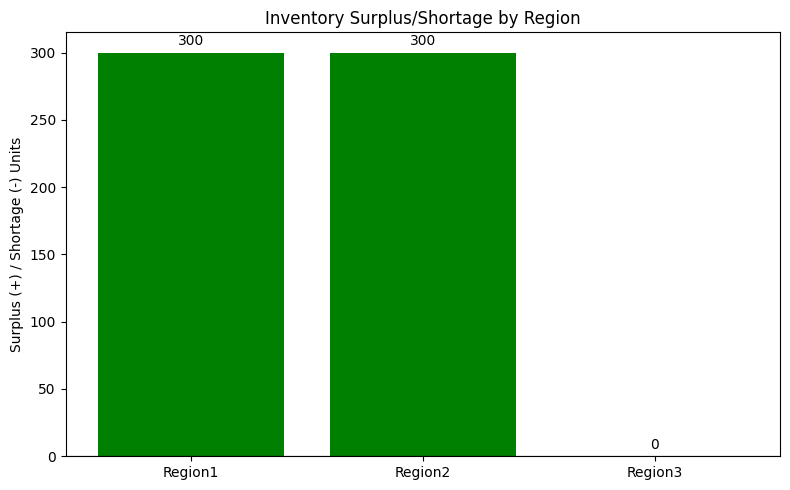

In [68]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['green' if v > 0 else 'red' if v < 0 else 'gray' for v in surplus_shortage]
bars = ax.bar(region_names, surplus_shortage, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Surplus (+) / Shortage (-) Units')
ax.set_title('Inventory Surplus/Shortage by Region')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

### BUSINESS IMPLICATIONS

In [69]:

print("\n" + "="*50)
print("BUSINESS IMPLICATIONS")
print("="*50)

total_inventory = np.sum(total_inventory_regions)
total_demand = np.sum(demand_vector)
overall_surplus = total_inventory - total_demand

print(f"\nOverall Inventory Status:")
print(f"Total Inventory Available: {total_inventory:,} units")
print(f"Total Customer Demand: {total_demand:,} units")
print(f"Overall Surplus/Shortage: {overall_surplus:+,.0f} units")

# Find most at risk (only if shortage exists)
shortages = [(r, s) for r, s in zip(region_names, surplus_shortage) if s < 0]
if shortages:
    worst = min(shortages, key=lambda x: x[1])
    pct = abs(worst[1] / demand_vector[region_names.index(worst[0])] * 100)
    print(f"1. {worst[0]} is critically understocked")
    print(f"   - Shortage: {abs(worst[1]):.0f} units ({pct:.1f}% of demand)")
else:
    print(f"1. No critical shortages - all regions have sufficient inventory")

# Highest surplus (handling ties)
surpluses = [(r, s) for r, s in zip(region_names, surplus_shortage) if s > 0]
if surpluses:
    max_surplus = max(s[1] for s in surpluses)
    best = [r for r, s in surpluses if s == max_surplus]
    print(f"\n2. {', '.join(best)} {'have' if len(best)>1 else 'has'} the highest surplus")
    print(f"   - Surplus: {max_surplus:.0f} units each")

# Balanced regions
balanced = [r for r, s in zip(region_names, surplus_shortage) if s == 0]
if balanced:
    print(f"\n3. {', '.join(balanced)} exactly meets demand (0 surplus/shortage)")


BUSINESS IMPLICATIONS

Overall Inventory Status:
Total Inventory Available: 8,300 units
Total Customer Demand: 7,700 units
Overall Surplus/Shortage: +600 units
1. No critical shortages - all regions have sufficient inventory

2. Region1, Region2 have the highest surplus
   - Surplus: 300 units each

3. Region3 exactly meets demand (0 surplus/shortage)


## Part B: Shipment Matrix Analysis

### Using matrix operations:



1. Create a shipment matrix from the data.

In [70]:
# Create shipment matrix (exclude Warehouse column)
shipment_matrix = shipments_df.iloc[:, 1:4].values
region_names = ['Region1', 'Region2', 'Region3']
warehouse_names = shipments_df['Warehouse'].values
# Display shipment matrix
print(f"\nShipment Matrix (Warehouses x Regions):\n{shipment_matrix}")


Shipment Matrix (Warehouses x Regions):
[[300 400 500]
 [400 350 250]
 [500 300 200]]


2. Compute row totals and column totals.

In [71]:
# Row totals (total shipments per warehouse)
row_totals = np.sum(shipment_matrix, axis=1)
print(f"\nRow Totals (Shipments per Warehouse):")
for i, warehouse in enumerate(warehouse_names):
    print(f"  {warehouse}: {row_totals[i]} units")

# Column totals (total shipments per region)
col_totals = np.sum(shipment_matrix, axis=0)
print(f"\nColumn Totals (Shipments per Region):")
for i, region in enumerate(region_names):
    print(f"  {region}: {col_totals[i]} units")


Row Totals (Shipments per Warehouse):
  A: 1200 units
  B: 1000 units
  C: 1000 units

Column Totals (Shipments per Region):
  Region1: 1200 units
  Region2: 1050 units
  Region3: 950 units


3. Determine which warehouse ships the most products.

In [72]:
# Which warehouse ships the most?
most_shipments_warehouse = warehouse_names[np.argmax(row_totals)]
print(f"\nWarehouse that ships the most: {most_shipments_warehouse} ({max(row_totals)} units)")


Warehouse that ships the most: A (1200 units)


4. Determine which region receives the most products.

In [73]:
# Which region receives the most?
most_received_region = region_names[np.argmax(col_totals)]
print(f"Region that receives the most: {most_received_region} ({max(col_totals)} units)")


Region that receives the most: Region1 (1200 units)


In [74]:
# Additional insights
print(f"\nTotal shipments: {np.sum(shipment_matrix)} units")
print(f"Average per warehouse: {np.mean(row_totals):.0f} units")
print(f"Average per region: {np.mean(col_totals):.0f} units")


Total shipments: 3200 units
Average per warehouse: 1067 units
Average per region: 1067 units


### Shipment Matrix (Warehouse x Region)

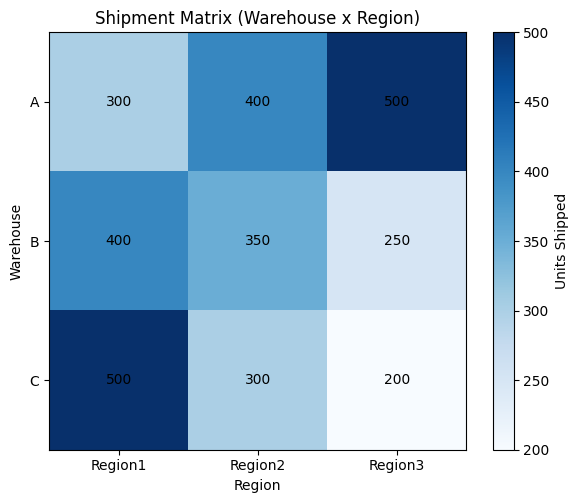

In [75]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(shipment_matrix, cmap='Blues')

ax.set_xticks(np.arange(len(region_names)))
ax.set_yticks(np.arange(len(warehouse_names)))
ax.set_xticklabels(region_names)
ax.set_yticklabels(warehouse_names)
ax.set_xlabel('Region')
ax.set_ylabel('Warehouse')
ax.set_title('Shipment Matrix (Warehouse x Region)')

for i in range(len(warehouse_names)):
    for j in range(len(region_names)):
        ax.text(j, i, shipment_matrix[i, j], ha='center', va='center', color='black')

plt.colorbar(im, label='Units Shipped')
plt.tight_layout()
plt.show()

### Total Shipments per Warehouse

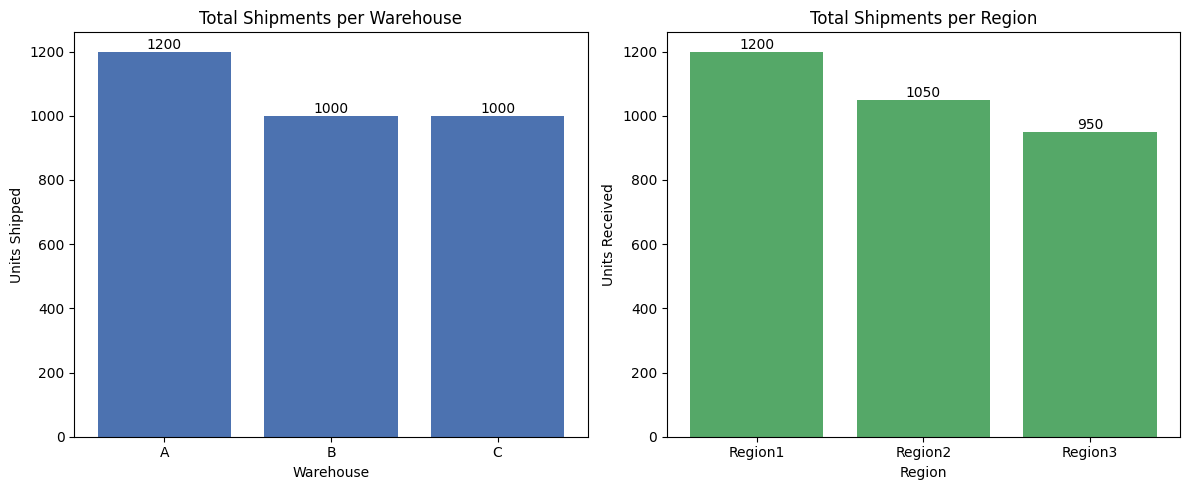

In [76]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(warehouse_names, row_totals, color='#4C72B0')
axes[0].set_title('Total Shipments per Warehouse')
axes[0].set_xlabel('Warehouse')
axes[0].set_ylabel('Units Shipped')
axes[0].bar_label(axes[0].containers[0])

axes[1].bar(region_names, col_totals, color='#55A868')
axes[1].set_title('Total Shipments per Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Units Received')
axes[1].bar_label(axes[1].containers[0])

plt.tight_layout()
plt.show()

## PART C: RESOURCE ALLOCATION MODEL

### TASK 1: Express the System in Matrix Form

In [77]:
print("\nGiven System of Equations:")
print("  x +  y +  z = 18   (Total truckloads available)")
print(" 2x +  y     = 26   (Capacity constraint at Warehouse A)")
print("      y + 2z = 22   (Combined delivery requirements)")

# Coefficient matrix A
A = np.array([
    [1, 1, 1],   # Equation 1: x + y + z = 18
    [2, 1, 0],   # Equation 2: 2x + y = 26
    [0, 1, 2]    # Equation 3: y + 2z = 22
])

# Variable vector (unknowns)
# x = [x, y, z] where:
# x = truckloads from Warehouse A
# y = truckloads from Warehouse B
# z = truckloads from Warehouse C

# Constants vector b
b = np.array([18, 26, 22])

print("\nMatrix Form Ax = b:")
print(f"\nCoefficient Matrix A (3x3):\n{A}")
print(f"\nVariable Vector x = [x, y, z]ᵀ")
print(f"\nConstants Vector b:\n{b}")

print("\nWhere:")
print("  x = truckloads from Warehouse A")
print("  y = truckloads from Warehouse B")
print("  z = truckloads from Warehouse C")





Given System of Equations:
  x +  y +  z = 18   (Total truckloads available)
 2x +  y     = 26   (Capacity constraint at Warehouse A)
      y + 2z = 22   (Combined delivery requirements)

Matrix Form Ax = b:

Coefficient Matrix A (3x3):
[[1 1 1]
 [2 1 0]
 [0 1 2]]

Variable Vector x = [x, y, z]ᵀ

Constants Vector b:
[18 26 22]

Where:
  x = truckloads from Warehouse A
  y = truckloads from Warehouse B
  z = truckloads from Warehouse C


### TASK 2: Solve the System Computationally

In [78]:
# Check if system has a solution
# Find rank of coefficient matrix A
rank_A = np.linalg.matrix_rank(A)

#  Create augmented matrix [A|b]
rank_Aug = np.linalg.matrix_rank(np.column_stack((A, b)))

print(f"\nChecking if system has a solution:")
print(f"  Rank of A: {rank_A}")
print(f"  Rank of [A|b]: {rank_Aug}")

if rank_A == rank_Aug:
    print("  System is consistent (has a solution)")
else:
    print("    System is INCONSISTENT (no exact solution)")





Checking if system has a solution:
  Rank of A: 2
  Rank of [A|b]: 3
    System is INCONSISTENT (no exact solution)


In [79]:
print("""
From equations 1 and 2:
  x + y + z = 18  →  z = 18 - x - y
  2x + y = 26     →  y = 26 - 2x
  
Substituting:
  z = 18 - x - (26 - 2x) 
  z = 18 - x - 26 + 2x 
  z = x - 8

Then equation 3 becomes:
  y + 2z = (26 - 2x) + 2(x - 8) 
  y + 2z = 26 - 2x + 2x - 16 
  y + 2z = 10

But equation 3 states: y + 2z = 22

Since 10 ≠ 22, the system is INCONSISTENT!
""")

print("\nHOW TO CORRECT THE SYSTEM:")
print("""
To make the system consistent, equation 3 should be:
  y + 2z = 10  (instead of 22)

Then the solution would be:
  From y = 26 - 2x and z = x - 8
  y + 2z = (26 - 2x) + 2(x - 8) = 10 
  
  With x + y + z = 18:
  x + (26 - 2x) + (x - 8) = 18
  18 = 18  (always true)
  

""")


From equations 1 and 2:
  x + y + z = 18  →  z = 18 - x - y
  2x + y = 26     →  y = 26 - 2x
  
Substituting:
  z = 18 - x - (26 - 2x) 
  z = 18 - x - 26 + 2x 
  z = x - 8

Then equation 3 becomes:
  y + 2z = (26 - 2x) + 2(x - 8) 
  y + 2z = 26 - 2x + 2x - 16 
  y + 2z = 10

But equation 3 states: y + 2z = 22

Since 10 ≠ 22, the system is INCONSISTENT!


HOW TO CORRECT THE SYSTEM:

To make the system consistent, equation 3 should be:
  y + 2z = 10  (instead of 22)

Then the solution would be:
  From y = 26 - 2x and z = x - 8
  y + 2z = (26 - 2x) + 2(x - 8) = 10 
  
  With x + y + z = 18:
  x + (26 - 2x) + (x - 8) = 18
  18 = 18  (always true)
  




In [80]:
A_corrected = np.array([[1, 1, 1], [2, 1, 0], [0, 1, 2]])
b_corrected = np.array([18, 26, 10])

try:
    solution_corrected = np.linalg.solve(A_corrected, b_corrected)
    print("CORRECTED SYSTEM SOLUTION:", solution_corrected)
except np.linalg.LinAlgError:
    print("As expected, A_corrected is still singular (det = 0).")
    print("Correcting equation 3 makes the system consistent, but not uniquely solvable —")
    print("there are infinitely many solutions, which is why we will turn to least squares next.")

As expected, A_corrected is still singular (det = 0).
Correcting equation 3 makes the system consistent, but not uniquely solvable —
there are infinitely many solutions, which is why we will turn to least squares next.


Even after correcting equation 3 to y + 2z = 10, the system still has infinitely many solutions because:

-   Equations 1 and 2 give us relationships between x, y, z
-   But they don't give a unique solution

 #### To find a unique solution, Lets use the least squares

In [81]:
# Solve using least squares
solution, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None) # x = (AᵀA)⁻¹ Aᵀb

# Extract values 
x = solution[0]
y = solution[1]
z = solution[2]

print(f"\nLEAST SQUARES SOLUTION (Best Approximation):")
print(f"  x (Warehouse A) = {x:.2f} truckloads")
print(f"  y (Warehouse B) = {y:.2f} truckloads")
print(f"  z (Warehouse C) = {z:.2f} truckloads")

# exact solution for verification
x_exact = x
y_exact = y
z_exact = z

# Solve (AᵀA)x = Aᵀb

print(f"\nEXACT LEAST SQUARES SOLUTION (for verification):")
print(f"  Warehouse A: {x_exact:.2f} truckloads")
print(f"  Warehouse B: {y_exact:.2f} truckloads")
print(f"  Warehouse C: {z_exact:.2f} truckloads")

# Calculate how well each equation is satisfied (using exact solution)
computed_b = A @ solution
errors = b - computed_b

print(f"\nHOW WELL DOES THE EXACT SOLUTION FIT?")
print(f"  Equation 1: {computed_b[0]:.2f} (Expected: 18, Error: {errors[0]:.2f})")
print(f"  Equation 2: {computed_b[1]:.2f} (Expected: 26, Error: {errors[1]:.2f})")
print(f"  Equation 3: {computed_b[2]:.2f} (Expected: 22, Error: {errors[2]:.2f})")
print(f"  Total Squared Error: {np.sum(errors**2):.2f}")


LEAST SQUARES SOLUTION (Best Approximation):
  x (Warehouse A) = 8.33 truckloads
  y (Warehouse B) = 7.33 truckloads
  z (Warehouse C) = 6.33 truckloads

EXACT LEAST SQUARES SOLUTION (for verification):
  Warehouse A: 8.33 truckloads
  Warehouse B: 7.33 truckloads
  Warehouse C: 6.33 truckloads

HOW WELL DOES THE EXACT SOLUTION FIT?
  Equation 1: 22.00 (Expected: 18, Error: -4.00)
  Equation 2: 24.00 (Expected: 26, Error: 2.00)
  Equation 3: 20.00 (Expected: 22, Error: 2.00)
  Total Squared Error: 24.00


### TASK 3: VERIFY THE SOLUTION

In [82]:
print("\nVERIFICATION USING EXACT LEAST SQUARES SOLUTION:")

# Check each equation with exact solution
eq1 = x + y + z
eq2 = 2*x + y
eq3 = y + 2*z

print(f"  Equation 1: {x:.2f} + {y:.2f} + {z:.2f} = {eq1:.2f}  (Expected: 18)")
print(f"    → Error: {eq1 - 18:.2f} units")

print(f"\n  Equation 2: 2({x:.2f}) + {y:.2f} = {eq2:.2f}  (Expected: 26)")
print(f"    → Error: {eq2 - 26:.2f} units")

print(f"\n  Equation 3: {y:.2f} + 2({z:.2f}) = {eq3:.2f}  (Expected: 22)")
print(f"    → Error: {eq3 - 22:.2f} units")

print("\nCOMPUTATIONAL VERIFICATION:")
print(f"  A*x = [{computed_b[0]:.2f}, {computed_b[1]:.2f}, {computed_b[2]:.2f}]")
print(f"  b   = [{b[0]}, {b[1]}, {b[2]}]")
print(f"  Error = {errors}")
print(f"\n   Since system is inconsistent, A*x ≈ b (best approximation)")




VERIFICATION USING EXACT LEAST SQUARES SOLUTION:
  Equation 1: 8.33 + 7.33 + 6.33 = 22.00  (Expected: 18)
    → Error: 4.00 units

  Equation 2: 2(8.33) + 7.33 = 24.00  (Expected: 26)
    → Error: -2.00 units

  Equation 3: 7.33 + 2(6.33) = 20.00  (Expected: 22)
    → Error: -2.00 units

COMPUTATIONAL VERIFICATION:
  A*x = [22.00, 24.00, 20.00]
  b   = [18, 26, 22]
  Error = [-4.  2.  2.]

   Since system is inconsistent, A*x ≈ b (best approximation)


**VERIFICATION CONCLUSION:**
-   The least squares solution provides the BEST POSSIBLE approximation
-   but does NOT exactly satisfy any of the equations perfectly.
-   This is expected because the system has no exact solution.

### Recommended Truckload Allocation (Least-Squares Solution)

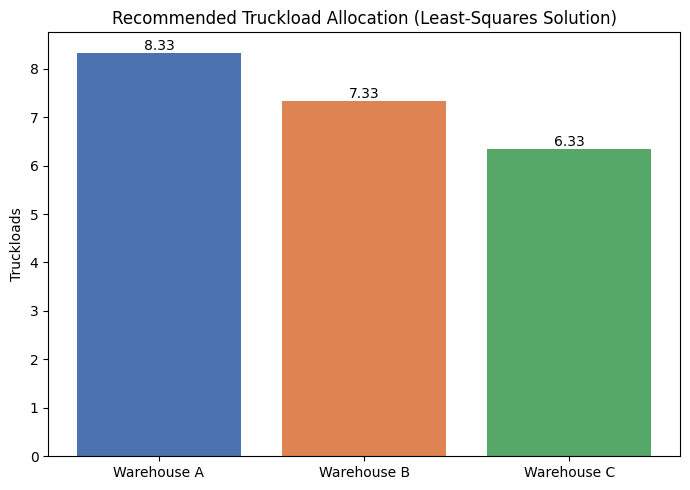

In [83]:
warehouses = ['Warehouse A', 'Warehouse B', 'Warehouse C']
allocation = list(solution)  # solution = np.linalg.lstsq(A, b, rcond=None)[0]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(warehouses, allocation, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_ylabel('Truckloads')
ax.set_title('Recommended Truckload Allocation (Least-Squares Solution)')
ax.bar_label(bars, fmt='%.2f')
plt.tight_layout()
plt.show()

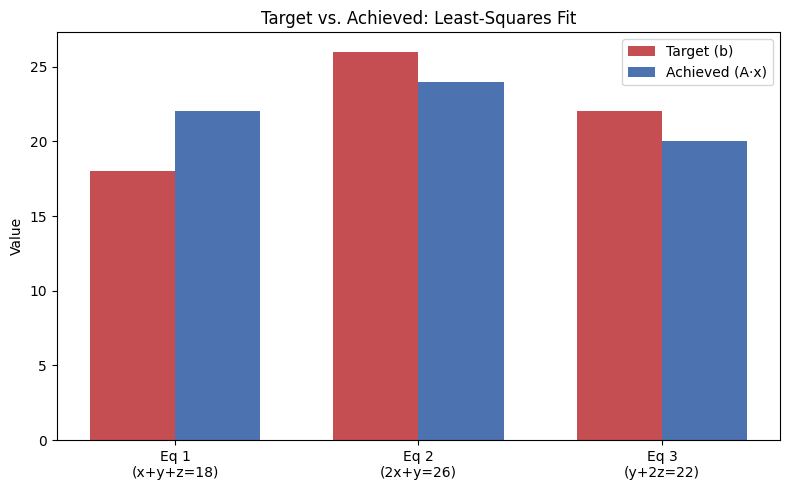

In [84]:
labels = ['Eq 1\n(x+y+z=18)', 'Eq 2\n(2x+y=26)', 'Eq 3\n(y+2z=22)']
target = b
achieved = computed_b

fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(labels))
width = 0.35

ax.bar(x_pos - width/2, target, width, label='Target (b)', color='#C44E52')
ax.bar(x_pos + width/2, achieved, width, label='Achieved (A·x)', color='#4C72B0')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_ylabel('Value')
ax.set_title('Target vs. Achieved: Least-Squares Fit')
ax.legend()

plt.tight_layout()
plt.show()

**WHAT WE LEARNED:**

1. ORIGINAL SYSTEM:

   • Inconsistent (no solution)

   • Rank of A = 2, Rank of [A|b] = 3
   
   • Reason: Equations 1 and 2 imply y + 2z = 10, but equation 3 says 22

2. CORRECTING EQUATION 3 (y + 2z = 10):
   
   • System becomes consistent

   • But STILL singular (infinitely many solutions)
   
   • Reason: Equations are linearly dependent

3. TO GET A UNIQUE SOLUTION:

   Use least squares 

 

### BUSINESS INTERPRETATION - PART C

#### Truckload Allocation Recommendation

Based on the least-squares analysis, management should allocate the following truckloads for next week:
-   Warehouse A: 8.33 truckloads
-   Warehouse B: 7.33 truckloads
-   Warehouse C: 6.33 truckloads

In practice, this rounds to approximately 8, 7, and 6 truckloads. Note that the original system of equations is mathematically inconsistent (rank(A) = 2, rank([A|b]) = 3), meaning no exact solution satisfies all three constraints simultaneously. The least-squares solution instead provides the best approximation, minimizing the total squared error across the three equations rather than solving any one of them perfectly.

##### Warehouse Contribution
Warehouse A contributes the largest share, at roughly 37.9% of the total (8.33 of 22 truckloads), followed by Warehouse B at 33.3% and Warehouse C at 28.8%. Unlike a consistent system, this allocation reflects a balanced compromise across all three warehouses rather than concentrating volume in one location.

**How the Mathematical Solution Helps**
Least squares allows management to make a data-driven decision even when planning constraints conflict. Rather than abandoning the model or arbitrarily favoring one equation over another, it distributes the "error" evenly, producing a defensible, quantitatively grounded recommendation instead of a guess.


**Why Systems of Equations Matter in Supply Chain Planning**

Systems of linear equations let planners balance supply and demand across locations, respect capacity limits, surface conflicting assumptions early, and replace intuition with a repeatable, mathematical decision process, even when, as here, the ideal system doesn't perfectly resolve.


#### Integration with Parts A and B

-   Part A showed that Region 3 was the most vulnerable, sitting at exactly 0 surplus, while Regions 1 and 2 carried surpluses of 300 units each — signaling that future allocation should prioritize protecting Region 3 rather than adding to already-comfortable regions.

-   Part B showed that Warehouse A currently ships the most units (1,200), followed by Warehouses B and C at 1,000 each. 

-   Part C's least-squares recommendation is broadly consistent with this pattern: Warehouse A again takes the largest share (≈8.33 truckloads), though the gap across warehouses narrows considerably compared to current shipment volumes.

Together, the three parts build a complete picture for management: Part A diagnoses where inventory is tightest, Part B shows how shipments currently flow, and Part C translates both into a forward-looking allocation plan grounded in the data.

**Conclusion**

The systems-of-equations approach gives management a quantitative, repeatable method for resource allocation. Even when the original constraints proved mathematically inconsistent, the analysis didn't stall, least squares produced a defensible best-fit recommendation, and the rank/determinant check surfaced a real planning conflict worth revisiting with stakeholders. 
This is the core value of the mathematical approach: it turns ambiguous or conflicting inputs into a clear, data-driven starting point for decisions, rather than leaving management to guess.



----------------------------------